# Bahrain Rental Price Prediction Challenge

 Ohood Majed Ahmed - DSB2

### 1. Setup & Imports

In [1]:
# Data handling libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')


### 2. Load Data


In [2]:
train = pd.read_csv("./data/data.csv")
test = pd.read_csv("./data/test.csv")

print("shape:", train.shape)
print("shape:", test.shape)


shape: (10578, 16)
shape: (3527, 15)


In [3]:
train.head()

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
0,6046,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Inclusive,BTRAND NEW LUXURY VILLA FOR RENT AMWAJ,"Amwaj Avenue, Amwaj Islands",Muharraq Governorate,3+ Maid,4,"2,368 sqft / 220 sqm",9 Apr 2025,Savio Fernandes,Almoayyed property solutions,6.0,1000.0
1,2240,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,First Resident | Quiet Area | Luxurious,Diyar Al Muharraq,Muharraq Governorate,5,6,"3,229 sqft / 300 sqm",16 Sep 2025,Al Lagoon Real Estate,Al Lagoon Real Estate,5.0,700.0
2,6248,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Studio Apartment for rent located in Juffair,Al Juffair,Capital Governorate,studio,1,484 sqft / 45 sqm,17 Aug 2025,Najeeb Hejres,Green Line Real Estate,12.0,260.0
3,7177,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Apartment for Rent in Jidhafs – Prime Location,Jidhafs,Northern Governorate,3,3,"1,507 sqft / 140 sqm",6 Aug 2025,Sayed Sadeq Jaafar,Grnata Real Estate,2.0,250.0
4,7842,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Navy Approved| 5 BR | Private Pool |Gardens,Al Juffair,Capital Governorate,5+ Maid,5,"4,844 sqft / 450 sqm",30 Jul 2025,Zsuzsanna Gecse,Arabian Homes Properties,13.0,1280.0


In [4]:
test.head()

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities
0,4394,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,PRIME LOCATION | NEWLY RENOVATED | MODERN 2BHK,"Sanabis, Manama",Capital Governorate,2,2,"1,313 sqft / 122 sqm",3 Sep 2025,Loai Bitar,Instant Homz,11.0
1,2338,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,2BR High-Rise | Juffair | Jacuzzi| Navy Approved,Al Juffair,Capital Governorate,2,2,"1,938 sqft / 180 sqm",15 Sep 2025,Shaji Kottathazham,AIM REAL ESTATE,12.0
2,8531,Rent,https://www.propertyfinder.bh/en/plp/rent/comp...,Compound,Exclusive,Beautiful modern villa in compound,Jannusan,Northern Governorate,3+ Maid,4,"3,767 sqft / 350 sqm",15 Jul 2025,Aysha Adil,301 REALESTATE,16.0
3,8952,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Affordable Spacious Bright In The Heart Of Saar,Saar,Northern Governorate,2,2,"1,292 sqft / 120 sqm",8 Jul 2025,Tariq Fatehi Abdelrahman Aboughazeh,Soulmate Management,6.0
4,11064,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,luxury | spacious design | Fully Furnished,Saar,Northern Governorate,1,1,"1,055 sqft / 98 sqm",8 Apr 2025,Aby N,4You Properties,5.0


### 3. Exploratory Data Analysis

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10578 entries, 0 to 10577
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Property_id        10578 non-null  int64  
 1   Offer              10578 non-null  str    
 2   URL                10578 non-null  str    
 3   Property_type      10578 non-null  str    
 4   Include_w_e        10578 non-null  str    
 5   Title              10575 non-null  str    
 6   Area               10575 non-null  str    
 7   Governorate        10575 non-null  str    
 8   Beds               10578 non-null  str    
 9   Baths              10578 non-null  str    
 10  Size               10578 non-null  str    
 11  Availability_date  10059 non-null  str    
 12  Agent_name         10575 non-null  str    
 13  Agency             10575 non-null  str    
 14  Amenities          10272 non-null  float64
 15  rent               10575 non-null  float64
dtypes: float64(2), int64(1), str(13)


In [6]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Property_id,10578.0,NaN,NaN,NaN,7059.73426,4080.910374,2.0,3521.25,7023.5,10605.75,14103.0
Offer,10578,1,Rent,10578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
URL,10578,10337,https://www.propertyfinder.bh/en/plp/rent/apar...,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Property_type,10578,11,Apartment,8378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Include_w_e,10578,2,Inclusive,6477,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,10575,9824,"Apartment for rent , in a great location:",18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,10575,127,Al Juffair,1914,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Governorate,10575,5,Capital Governorate,5308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Beds,10578,19,2,3874,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Baths,10578,9,2,4260,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Missing values summary
missing = train.isnull().sum()
missing_percent = (missing / len(train)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_percent.round(2)})
missing_df

,Missing Count,Percentage
Property_id,0,0.00
Offer,0,0.00
URL,0,0.00
Property_type,0,0.00
Include_w_e,0,0.00
Title,3,0.03
Area,3,0.03
Governorate,3,0.03
Beds,0,0.00
Baths,0,0.00


In [8]:
test.isnull().sum()

Property_id            0
Offer                  0
URL                    0
Property_type          0
Include_w_e            0
Title                  0
Area                   0
Governorate            0
Beds                   0
Baths                  0
Size                   0
Availability_date    168
Agent_name             0
Agency                 0
Amenities             86
dtype: int64

In [9]:
train[train['rent'].isna()]

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
5194,125,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,NaN,NaN,NaN,2,4,"1,399 sqft / 130 sqm",NaN,NaN,NaN,5.0,NaN
6787,25,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,NaN,NaN,NaN,2,4,"1,399 sqft / 130 sqm",NaN,NaN,NaN,5.0,NaN
7864,9012,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,NaN,NaN,NaN,2,2,"1,184 sqft / 110 sqm",NaN,NaN,NaN,8.0,NaN


In [10]:
train.dropna(subset=['rent'], inplace=True)

In [11]:
train[train['rent'].isna()]

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent


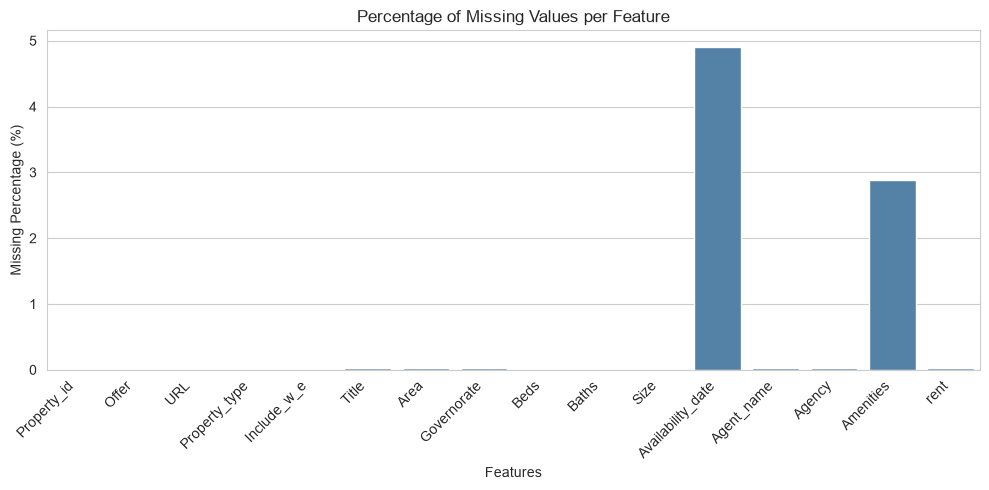

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df.index, y=missing_df['Percentage'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Features')
plt.title('Percentage of Missing Values per Feature')
plt.tight_layout()
plt.show()

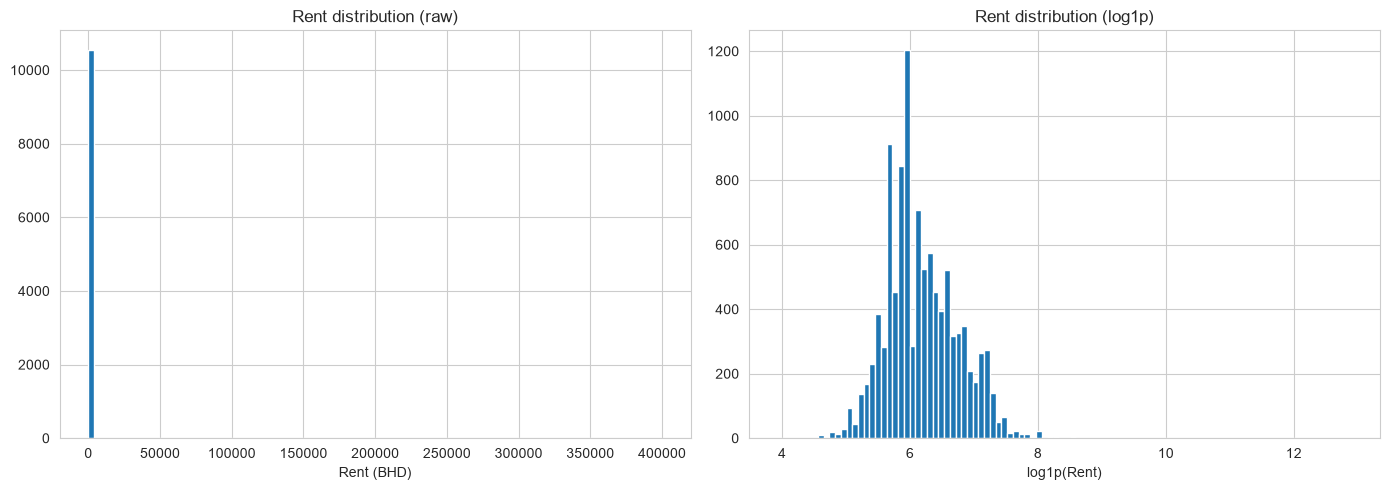

In [13]:
# Rent distribution (log scale) to see the spread and outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train['rent'].dropna(), bins=100)
axes[0].set_title('Rent distribution (raw)')
axes[0].set_xlabel('Rent (BHD)')

axes[1].hist(np.log1p(train['rent'].dropna()), bins=100)
axes[1].set_title('Rent distribution (log1p)')
axes[1].set_xlabel('log1p(Rent)')
plt.tight_layout()
plt.show()


In [14]:
print("Total duplicate rows:", train.duplicated().sum())
print("Duplicate rows:", train.drop(columns=['Property_id', 'URL']).duplicated().sum())

Total duplicate rows: 0
Duplicate rows: 268


In [15]:
train.columns

Index(['Property_id', 'Offer', 'URL', 'Property_type', 'Include_w_e', 'Title',
       'Area', 'Governorate', 'Beds', 'Baths', 'Size', 'Availability_date',
       'Agent_name', 'Agency', 'Amenities', 'rent'],
      dtype='str')

In [16]:
train['Amenities'].value_counts()

Amenities
11.0    781
12.0    774
13.0    727
10.0    702
9.0     652
14.0    641
16.0    588
15.0    557
8.0     544
17.0    542
1.0     527
7.0     523
6.0     488
5.0     483
3.0     416
4.0     371
2.0     309
18.0    278
19.0    160
20.0     73
25.0     43
21.0     36
24.0     25
22.0     15
23.0     14
Name: count, dtype: int64

In [17]:
train['Area'].value_counts()

Area
Al Juffair                                              1914
Seef                                                    1025
Saar                                                     704
Janabiya                                                 535
Hidd                                                     496
                                                        ... 
Buri                                                       1
Al Thurya villa Diyar Al Muharraq, Diyar Al Muharraq       1
Dareena, Dilmunia Island                                   1
Wahat Al Muharraq                                          1
Adhari, Manama                                             1
Name: count, Length: 127, dtype: int64

In [18]:
train['Size'].value_counts()

Size
1,292 sqft / 120 sqm       923
1,399 sqft / 130 sqm       568
1,076 sqft / 100 sqm       436
1,184 sqft / 110 sqm       402
1,507 sqft / 140 sqm       364
                          ... 
4,510 sqft / 419 sqm         1
4,176 sqft / 388 sqm         1
2,626 sqft / 244 sqm         1
26,910 sqft / 2,500 sqm      1
6,383 sqft / 593 sqm         1
Name: count, Length: 395, dtype: int64

In [19]:
train['Baths'].value_counts()

Baths
2       4259
3       2427
1       1583
4       1217
5        739
6        222
7         83
7+        44
none       1
Name: count, dtype: int64

In [20]:
train['Beds'].value_counts()

Beds
2               3871
1               2201
3               1332
4+ Maid          832
3+ Maid          748
studio           595
2+ Maid          283
5+ Maid          253
4                236
5                 63
1+ Maid           49
6+ Maid           41
6                 20
7+                18
studio+ Maid       9
7++ Maid           7
7                  7
7+ Maid            7
0                  3
Name: count, dtype: int64

<Axes: >

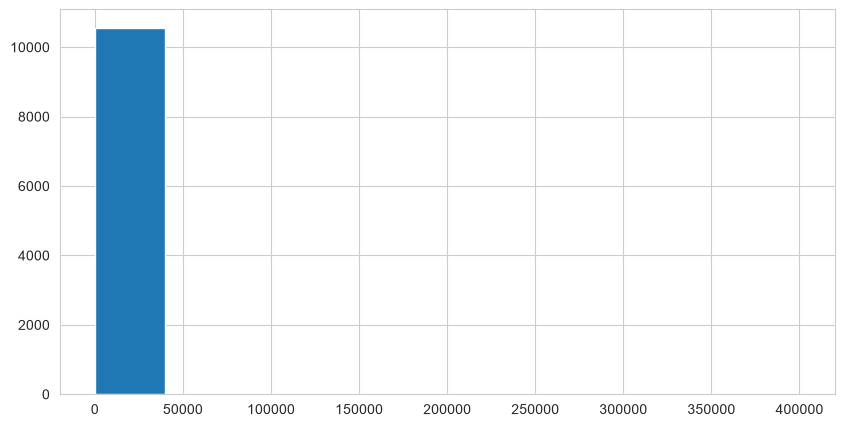

In [21]:
train["rent"].describe()

train["rent"].hist()

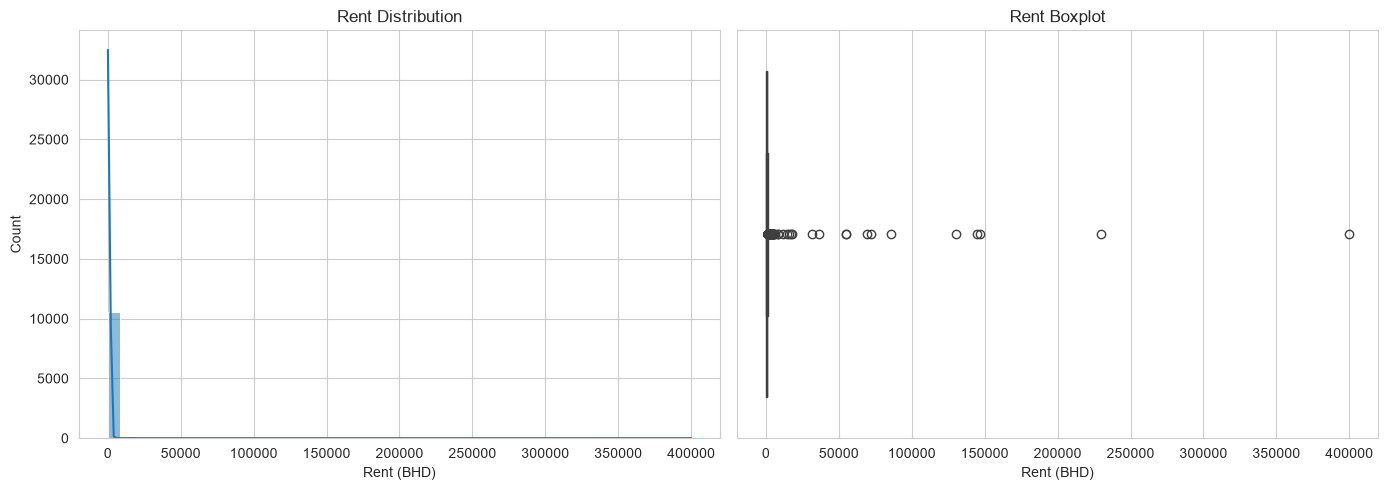

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rent distribution plot
sns.histplot(train['rent'].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title('Rent Distribution')
axes[0].set_xlabel('Rent (BHD)')

# Rent boxplot
sns.boxplot(x=train['rent'].dropna(), ax=axes[1])
axes[1].set_title('Rent Boxplot')
axes[1].set_xlabel('Rent (BHD)')

plt.tight_layout()
plt.show()


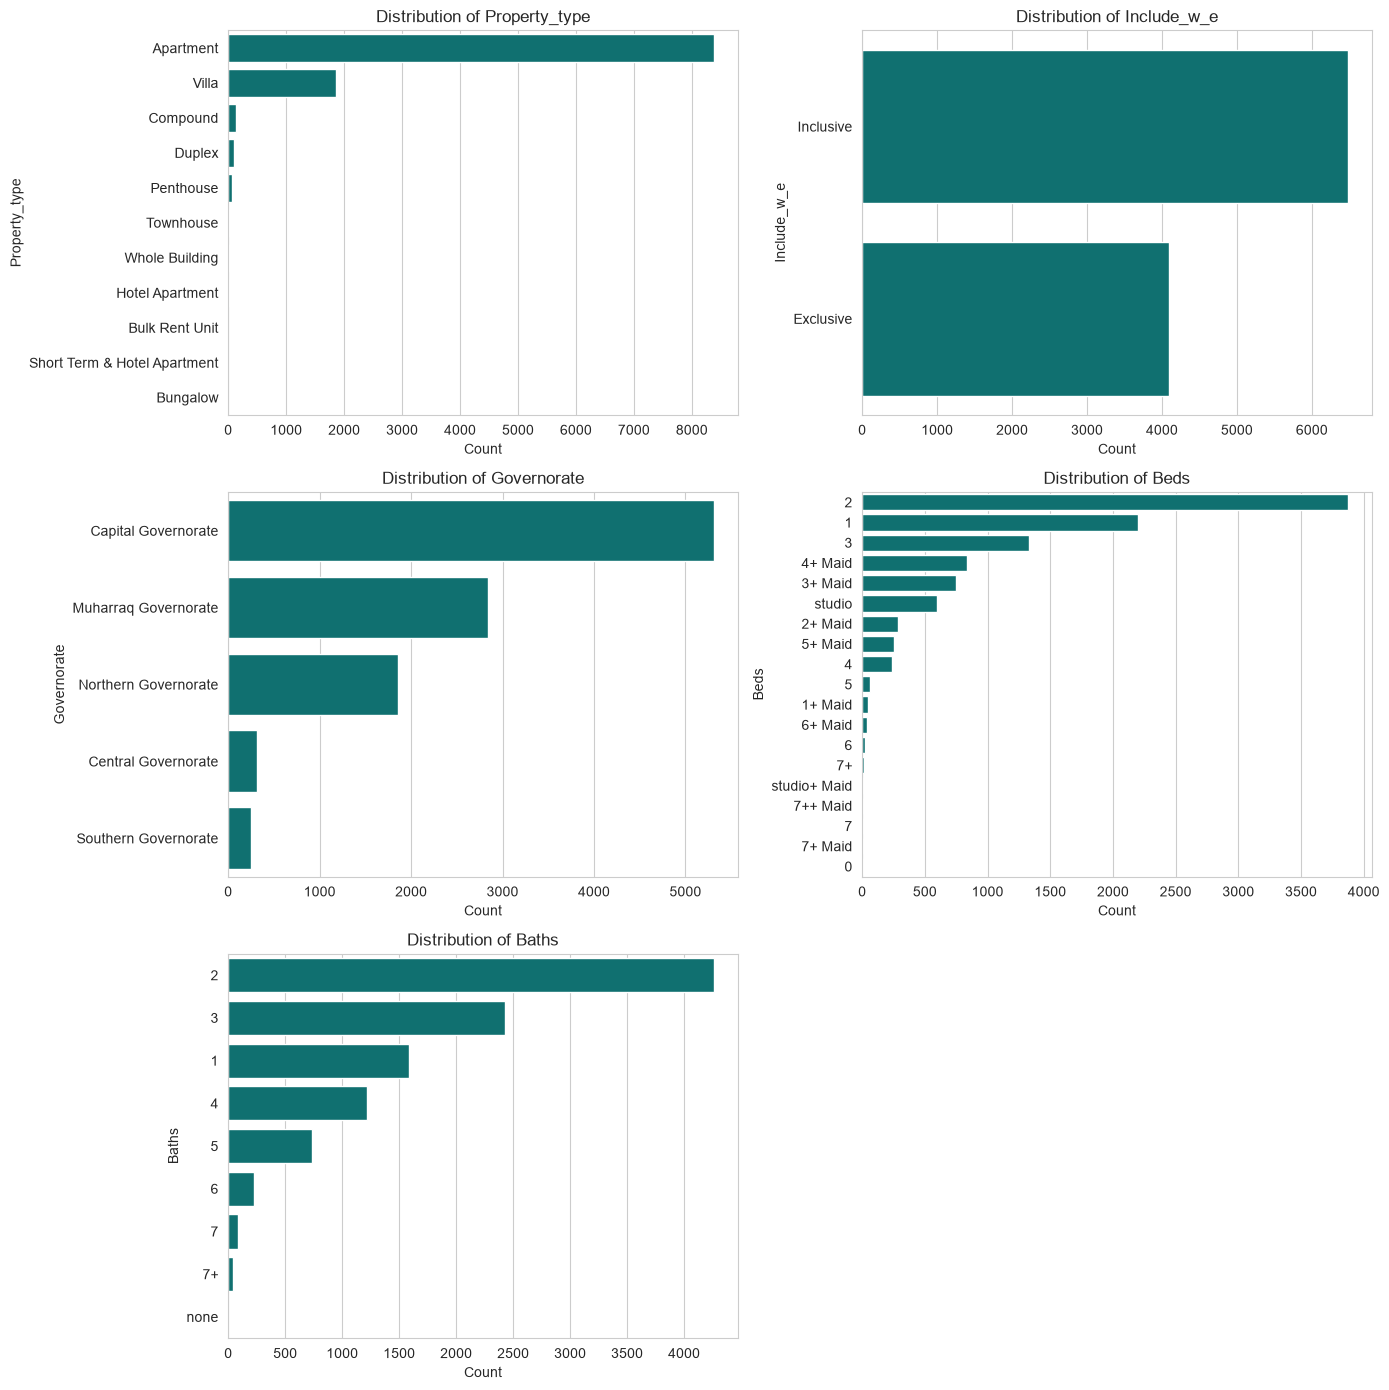

In [23]:
categorical_cols_overview = ['Property_type', 'Include_w_e', 'Governorate', 'Beds', 'Baths']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_overview):
    order = train[col].value_counts().index
    sns.countplot(y=train[col], order=order, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(col)

# Hide the unused last subplot (6th axis)
axes[-1].axis('off')

plt.tight_layout()
plt.show()

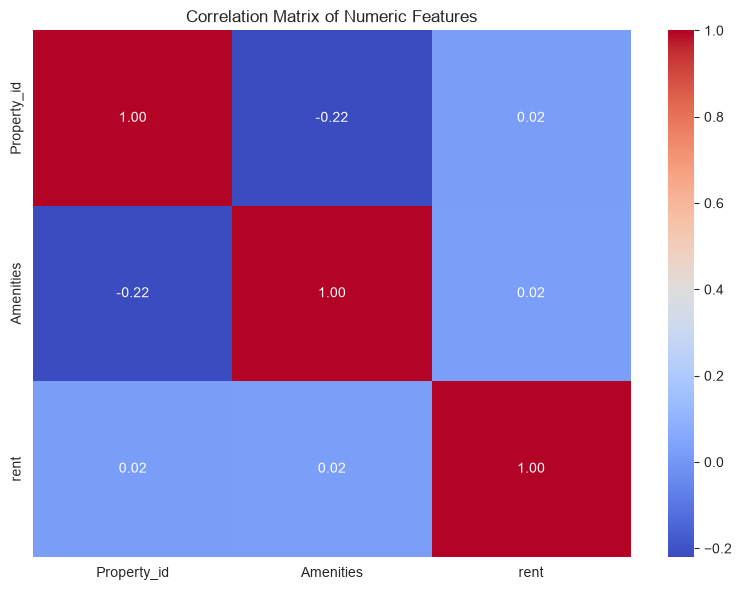

In [24]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(8, 6))
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

In [25]:
# Drop the 3 fully-blank rows (rent is NaN on these — unusable for training)
train.dropna(subset=['rent'], inplace=True)

# Drop exact duplicate listings (ignore Property_id/URL, which are unique per-listing identifiers)
dup_cols = [c for c in train.columns if c not in ['Property_id', 'URL']]
before = train.shape[0]
train = train.drop_duplicates(subset=dup_cols).reset_index(drop=True)
print(f"Dropped {before - train.shape[0]} exact duplicate listings")
print("Remaining train rows:", train.shape[0])


Dropped 268 exact duplicate listings
Remaining train rows: 10307


In [26]:
def extract_beds(x):
    x = str(x).lower().strip()
    if 'studio' in x:
        return 0
    digits = ''.join(c for c in x if c.isdigit())
    return int(digits) if digits else np.nan

def extract_has_maid(x):
    return 1 if 'maid' in str(x).lower() else 0

def extract_baths(x):
    x = str(x).lower().strip()
    if x in ('none', 'nan', ''):
        return np.nan         
    digits = ''.join(c for c in x if c.isdigit())
    return int(digits) if digits else np.nan

def extract_size_sqft(x):
    try:
        sqft_part = str(x).split('sqft')[0].replace(',', '').strip()
        val = float(sqft_part)
        if val < 150:
            return np.nan
        return val
    except Exception:
        return np.nan

for df in [train, test]:
    df['Beds_num'] = df['Beds'].apply(extract_beds)
    df['Has_Maid_Room'] = df['Beds'].apply(extract_has_maid)
    df['Baths_num'] = df['Baths'].apply(extract_baths)
    df['Size_sqft'] = df['Size'].apply(extract_size_sqft)
    df['Is_Inclusive'] = (df['Include_w_e'].astype(str).str.strip().str.lower() == 'inclusive').astype(int)

print('Missing after parsing (train):')
print(train[['Beds_num', 'Baths_num', 'Size_sqft']].isnull().sum())


Missing after parsing (train):
Beds_num       0
Baths_num      1
Size_sqft    115
dtype: int64


In [27]:
baths_group_median = train.groupby(['Property_type', 'Beds_num'])['Baths_num'].median()
global_baths_median = train['Baths_num'].median()
size_group_median = train.groupby(['Property_type', 'Beds_num'])['Size_sqft'].median()
global_size_median = train['Size_sqft'].median()

for df in [train, test]:
    baths_idx = df['Baths_num'].isna()
    if baths_idx.any():
        df.loc[baths_idx, 'Baths_num'] = df.loc[baths_idx].apply(
            lambda r: baths_group_median.get((r['Property_type'], r['Beds_num']), np.nan), axis=1)
        df['Baths_num'] = df['Baths_num'].fillna(global_baths_median)

    size_idx = df['Size_sqft'].isna()
    if size_idx.any():
        df.loc[size_idx, 'Size_sqft'] = df.loc[size_idx].apply(
            lambda r: size_group_median.get((r['Property_type'], r['Beds_num']), np.nan), axis=1)
        df['Size_sqft'] = df['Size_sqft'].fillna(global_size_median)

type_counts = train['Property_type'].value_counts()
rare_types = type_counts[type_counts < 15].index.tolist()
print('Rare property types merged into "Other":', rare_types)
for df in [train, test]:
    df['Property_type'] = df['Property_type'].apply(lambda v: 'Other' if v in rare_types else v)

for col in ['Title', 'Area', 'Governorate', 'Agent_name', 'Agency']:
    mode_val = train[col].mode()[0]
    for df in [train, test]:
        df[col] = df[col].fillna(mode_val)

amenities_group_median = train.groupby('Property_type')['Amenities'].median()
global_amenities_median = train['Amenities'].median()
for df in [train, test]:
    idx = df['Amenities'].isna()
    if idx.any():
        df.loc[idx, 'Amenities'] = df.loc[idx, 'Property_type'].map(amenities_group_median)
        df['Amenities'] = df['Amenities'].fillna(global_amenities_median)

for df in [train, test]:
    df['Availability_date'] = pd.to_datetime(df['Availability_date'], errors='coerce')
    df['Availability_Missing'] = df['Availability_date'].isna().astype(int)
avail_mode = train['Availability_date'].mode()[0]
for df in [train, test]:
    df['Availability_date'] = df['Availability_date'].fillna(avail_mode)

print('Missing values handled. Remaining in train:', train.isnull().sum().sum())


Rare property types merged into "Other": ['Hotel Apartment', 'Bulk Rent Unit', 'Short Term & Hotel Apartment', 'Bungalow']
Missing values handled. Remaining in train: 0


In [28]:
def extract_title_flags(title):
    t = str(title).lower()
    return pd.Series({
        'Title_luxury': int(any(w in t for w in ['luxury', 'luxuary', 'luxurious', 'premium', 'exclusive'])),
        'Title_furnished': int('furnished' in t and 'unfurnished' not in t),
        'Title_spacious': int('spacious' in t or 'specious' in t),   # 'specious' is a common typo for 'spacious' (94 occurrences in train, verified)
        'Title_brand_new': int('brand new' in t or 'new build' in t or 'brand-new' in t),
        'Title_sea_view': int(any(w in t for w in ['sea view', 'seaview', 'sea-view', 'beach'])),
        'Title_pool': int('pool' in t),
        'Title_gym': int('gym' in t),
        'Title_balcony': int('balcony' in t),
        'Title_parking': int('parking' in t),
        'Title_garden': int('garden' in t),
    })

for df in [train, test]:
    df['Availability_Month'] = df['Availability_date'].dt.month
    title_flags = df['Title'].apply(extract_title_flags)
    df[title_flags.columns] = title_flags

agency_counts = train['Agency'].value_counts()
agent_counts = train['Agent_name'].value_counts()

for df in [train, test]:
    df['TotalRooms'] = df['Beds_num'] + df['Baths_num']
    df['AreaPerRoom'] = df['Size_sqft'] / (df['Beds_num'] + 1)
    df['Bath_to_Bed_ratio'] = df['Baths_num'] / (df['Beds_num'] + 1)
    df['Amenities_per_Room'] = df['Amenities'] / (df['TotalRooms'] + 1)
    df['Size_per_TotalRoom'] = df['Size_sqft'] / (df['TotalRooms'] + 1)
    df['Area_PropType'] = df['Area'].astype(str) + '_' + df['Property_type'].astype(str)
    df['Month_sin'] = np.sin(2 * np.pi * df['Availability_Month'] / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Availability_Month'] / 12)
    df['Size_sqft_log'] = np.log1p(df['Size_sqft'])

    area_parts = df['Area'].astype(str).str.split(',', n=1, expand=True)
    df['Sub_Area'] = area_parts[0].str.strip()
    df['Main_Area'] = area_parts[1].str.strip() if area_parts.shape[1] > 1 else df['Area']
    df['Main_Area'] = df['Main_Area'].fillna(df['Area'])

    df['Agency_freq_log'] = np.log1p(df['Agency'].map(agency_counts).fillna(0))
    df['Agent_freq_log'] = np.log1p(df['Agent_name'].map(agent_counts).fillna(0))

    df['Bed_Bath_interaction'] = df['Beds_num'] * df['Baths_num']

train[['TotalRooms', 'AreaPerRoom', 'Bath_to_Bed_ratio', 'Size_sqft', 'Size_sqft_log',
       'Main_Area', 'Sub_Area', 'Agency_freq_log', 'Bed_Bath_interaction']].head()


,TotalRooms,AreaPerRoom,Bath_to_Bed_ratio,Size_sqft,Size_sqft_log,Main_Area,Sub_Area,Agency_freq_log,Bed_Bath_interaction
0,7.0,592.000000,1.000000,2368.0,7.770223,Amwaj Islands,Amwaj Avenue,4.174387,12.0
1,11.0,538.166667,1.000000,3229.0,8.080237,Diyar Al Muharraq,Diyar Al Muharraq,3.663562,30.0
2,1.0,484.000000,1.000000,484.0,6.184149,Al Juffair,Al Juffair,4.488636,0.0
3,6.0,376.750000,0.750000,1507.0,7.318540,Jidhafs,Jidhafs,5.929589,9.0
4,10.0,807.333333,0.833333,4844.0,8.485703,Al Juffair,Al Juffair,5.176150,25.0


In [29]:
cols_to_drop = [
    'URL', 'Agent_name', 'Offer',
    'Beds', 'Baths', 'Size', 'Availability_date', 'Include_w_e'
]

train_clean = train.drop(columns=[c for c in cols_to_drop if c in train.columns])
test_clean = test.drop(columns=[c for c in cols_to_drop if c in test.columns])

print('Columns in train_clean:', list(train_clean.columns))


Columns in train_clean: ['Property_id', 'Property_type', 'Title', 'Area', 'Governorate', 'Agency', 'Amenities', 'rent', 'Beds_num', 'Has_Maid_Room', 'Baths_num', 'Size_sqft', 'Is_Inclusive', 'Availability_Missing', 'Availability_Month', 'Title_luxury', 'Title_furnished', 'Title_spacious', 'Title_brand_new', 'Title_sea_view', 'Title_pool', 'Title_gym', 'Title_balcony', 'Title_parking', 'Title_garden', 'TotalRooms', 'AreaPerRoom', 'Bath_to_Bed_ratio', 'Amenities_per_Room', 'Size_per_TotalRoom', 'Area_PropType', 'Month_sin', 'Month_cos', 'Size_sqft_log', 'Sub_Area', 'Main_Area', 'Agency_freq_log', 'Agent_freq_log', 'Bed_Bath_interaction']


In [30]:
logr = np.log1p(train_clean['rent'])
Q1, Q3 = logr.quantile([0.25, 0.75])
IQR = Q3 - Q1
lo, hi = Q1 - 3 * IQR, Q3 + 3 * IQR

before = train_clean.shape[0]
train_clean = train_clean[(logr >= lo) & (logr <= hi)].reset_index(drop=True)
print(f"Removed {before - train_clean.shape[0]} extreme rent outliers (3xIQR on log1p(rent))")


Removed 18 extreme rent outliers (3xIQR on log1p(rent))


In [31]:
# Outlier pass on rent-per-sqft, also on the log scale (catches mismatched size/rent combos)
rps = train_clean['rent'] / train_clean['Size_sqft'].replace(0, np.nan)
log_rps = np.log1p(rps)
Q1p, Q3p = log_rps.quantile([0.25, 0.75])
IQRp = Q3p - Q1p
lo_p, hi_p = Q1p - 3 * IQRp, Q3p + 3 * IQRp

before = train_clean.shape[0]
train_clean = train_clean[log_rps.isna() | ((log_rps >= lo_p) & (log_rps <= hi_p))].reset_index(drop=True)
print(f"Removed {before - train_clean.shape[0]} rent-per-sqft outliers (3xIQR on log1p(rent/sqft))")

train_clean['rent_log'] = np.log1p(train_clean['rent'])
print('Final training rows after cleaning:', train_clean.shape[0])


Removed 15 rent-per-sqft outliers (3xIQR on log1p(rent/sqft))
Final training rows after cleaning: 10274


In [32]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetMeanEncoder(BaseEstimator, TransformerMixin):
    """Smoothed mean-target encoder, fit on training data only (no leakage)."""

    def __init__(self, smoothing=10):
        self.smoothing = smoothing

    def fit(self, X, y):
        X = pd.DataFrame(X)
        y = pd.Series(np.asarray(y).ravel(), index=X.index)
        self.global_mean_ = y.mean()
        self.mappings_ = {}
        for col in X.columns:
            counts = y.groupby(X[col]).count()
            means = y.groupby(X[col]).mean()
            self.mappings_[col] = (means * counts + self.global_mean_ * self.smoothing) / (counts + self.smoothing)
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        out = np.zeros(X.shape)
        for i, col in enumerate(X.columns):
            out[:, i] = X[col].map(self.mappings_[col]).fillna(self.global_mean_).values
        return out

    def get_feature_names_out(self, input_features=None):
        cols = input_features if input_features is not None else list(self.mappings_.keys())
        return np.array([f"{c}_target_enc" for c in cols])

### 5. Modeling: Gradient-Boosted Trees + Stacked Ensemble

**What changed from the previous version, and why:**

- The old notebook picked its winner from `{Linear/Ridge/Lasso/ElasticNet, KNN, Decision Tree, Random Forest}`. None of those are close to state-of-the-art for structured/tabular data like this. **Gradient-boosted trees (LightGBM, XGBoost, CatBoost)** are the standard choice for tabular regression competitions and consistently beat Random Forest / KNN / plain linear models on data like rent listings — this alone is usually the single biggest score jump available.
- Each of the three boosters is tuned with `RandomizedSearchCV` (5-fold CV, MAE scoring on the log target).
- The three tuned boosters are combined with a `StackingRegressor` (a `RidgeCV` meta-model learns the best blend of the three, using out-of-fold predictions — this is a more principled version of the manual weight-search grid the old notebook used for the KNN+DT+RF `VotingRegressor`).
- **Bug fix:** the old ensemble cell (5c) referenced `tuned_pipelines['KNN (Tuned via GridSearchCV)']` etc., but the tuning loop right before it (5b) never actually stored anything into `tuned_pipelines` under those names (the loop ended on a bare `label` statement that did nothing) — that cell would raise a `KeyError` if run top to bottom. That whole section is replaced below.

In [33]:
categorical_features = ['Property_type']
target_encoded_features = ['Area', 'Governorate', 'Agency', 'Area_PropType', 'Main_Area', 'Sub_Area']
numeric_features = ['Beds_num', 'Baths_num', 'TotalRooms', 'AreaPerRoom', 'Has_Maid_Room',
                     'Month_sin', 'Month_cos', 'Bath_to_Bed_ratio', 'Amenities_per_Room', 'Size_per_TotalRoom',
                     'Title_luxury', 'Title_furnished', 'Title_brand_new', 'Title_sea_view',
                     'Title_spacious', 'Title_pool', 'Title_gym', 'Title_balcony', 'Title_parking', 'Title_garden',
                     'Agency_freq_log', 'Agent_freq_log', 'Size_sqft_log', 'Availability_Missing', 'Is_Inclusive',
                     'Bed_Bath_interaction']
skewed_features = ['Size_sqft', 'Amenities']

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
target_enc_transformer = Pipeline(steps=[
    ('target_enc', TargetMeanEncoder(smoothing=10)),
    ('scaler', StandardScaler())
])
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
skewed_transformer = Pipeline(steps=[
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, categorical_features),
    ('target_enc', target_enc_transformer, target_encoded_features),
    ('num', numeric_transformer, numeric_features),
    ('skewed', skewed_transformer, skewed_features),
])

feature_cols = categorical_features + target_encoded_features + numeric_features + skewed_features

X = train_clean[feature_cols]
y = train_clean['rent_log']            # train on log-transformed target
y_original = train_clean['rent']       # keep original scale to evaluate MAE in BHD

X_train, X_val, y_train, y_val, y_train_orig, y_val_orig = train_test_split(
    X, y, y_original, test_size=0.2, random_state=42
)

print('Training dataset shape:', X_train.shape)
print('Validation dataset shape:', X_val.shape)


Training dataset shape: (8219, 35)
Validation dataset shape: (2055, 35)


In [34]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import StackingRegressor

def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}")
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []

In [35]:
# Baseline for reference: Ridge (fast, keeps a linear-model sanity check in the comparison table)
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', Ridge(alpha=1.0, random_state=42))])
ridge_pipeline.fit(X_train, y_train)
pred_ridge = np.clip(np.expm1(ridge_pipeline.predict(X_val)), 0, None)
results.append(evaluate_model(y_val_orig, pred_ridge, 'Ridge (baseline)'))

--- Ridge (baseline) ---
MAE  : 112.86
RMSE : 195.18
R2   : 0.7380


In [36]:
lgbm_grid = {
    'model__n_estimators': [500, 800, 1200, 1600],
    'model__learning_rate': [0.015, 0.02, 0.03, 0.05],
    'model__num_leaves': [31, 45, 63, 80],
    'model__min_child_samples': [5, 10, 20, 30],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__reg_alpha': [0, 0.1, 0.3, 0.5],
    'model__reg_lambda': [0.1, 0.3, 0.5, 1],
}

xgb_grid = {
    'model__n_estimators': [500, 800, 1200, 1600],
    'model__learning_rate': [0.015, 0.02, 0.03, 0.05],
    'model__max_depth': [4, 5, 6, 7],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__reg_alpha': [0, 0.1, 0.3, 0.5],
    'model__reg_lambda': [0.5, 1, 1.5, 2],
}

cat_grid = {
    'model__iterations': [500, 800, 1200, 1600],
    'model__learning_rate': [0.015, 0.02, 0.03, 0.05],
    'model__depth': [4, 5, 6, 8],
    'model__l2_leaf_reg': [1, 3, 5, 7],
}

search_configs = {
    'LightGBM': (LGBMRegressor(random_state=42, n_jobs=1, verbosity=-1), lgbm_grid),
    'XGBoost': (XGBRegressor(random_state=42, n_jobs=1, verbosity=0), xgb_grid),
    'CatBoost': (CatBoostRegressor(random_state=42, verbose=0), cat_grid),
}

cv = KFold(n_splits=4, shuffle=True, random_state=42)
tuned_pipelines = {}

for name, (estimator, grid) in search_configs.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', estimator)])
    search = RandomizedSearchCV(
        pipe, param_distributions=grid, n_iter=15,
        scoring='neg_mean_absolute_error', cv=cv, n_jobs=1, random_state=42
    )
    search.fit(X_train, y_train)
    tuned_pipelines[name] = search.best_estimator_

    pred = np.clip(np.expm1(search.best_estimator_.predict(X_val)), 0, None)
    results.append(evaluate_model(y_val_orig, pred, f'{name} (Tuned)'))
    print(f'{name} best params:', search.best_params_)
    print()


--- LightGBM (Tuned) ---
MAE  : 92.94
RMSE : 178.26
R2   : 0.7815
LightGBM best params: {'model__subsample': 0.7, 'model__reg_lambda': 1, 'model__reg_alpha': 0.1, 'model__num_leaves': 45, 'model__n_estimators': 1600, 'model__min_child_samples': 5, 'model__learning_rate': 0.015, 'model__colsample_bytree': 0.7}

--- XGBoost (Tuned) ---
MAE  : 93.92
RMSE : 178.46
R2   : 0.7810
XGBoost best params: {'model__subsample': 0.7, 'model__reg_lambda': 1, 'model__reg_alpha': 0.1, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 7, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.7}

--- CatBoost (Tuned) ---
MAE  : 93.49
RMSE : 179.21
R2   : 0.7792
CatBoost best params: {'model__learning_rate': 0.03, 'model__l2_leaf_reg': 1, 'model__iterations': 1600, 'model__depth': 8}



In [37]:
results_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,LightGBM (Tuned),92.939018,178.261676,0.781489
1,CatBoost (Tuned),93.487261,179.205992,0.779168
2,XGBoost (Tuned),93.922063,178.459268,0.781004
3,Ridge (baseline),112.862117,195.184193,0.738033


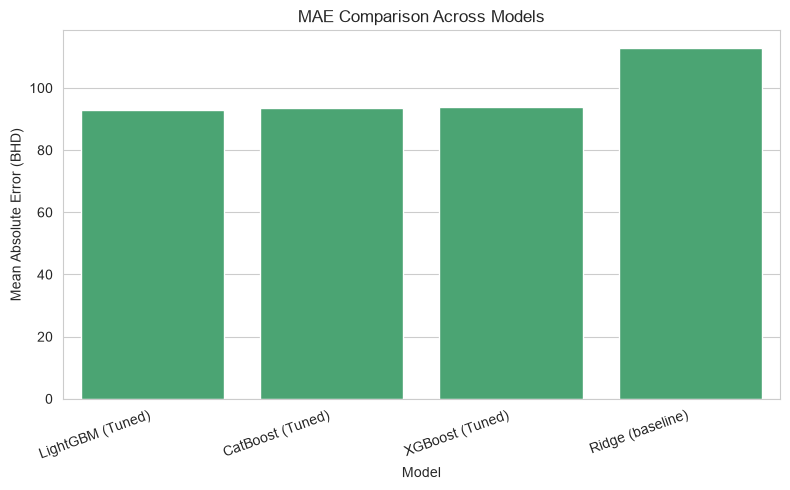

In [38]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Model', y='MAE', color='mediumseagreen')
plt.xticks(rotation=20, ha='right')
plt.title('MAE Comparison Across Models')
plt.ylabel('Mean Absolute Error (BHD)')
plt.xlabel('Model')
plt.tight_layout()
plt.show()

In [39]:
stacking_model = StackingRegressor(
    estimators=[
        ('lightgbm', tuned_pipelines['LightGBM']),
        ('xgboost', tuned_pipelines['XGBoost']),
        ('catboost', tuned_pipelines['CatBoost']),
    ],
    final_estimator=RidgeCV(alphas=np.logspace(-3, 3, 25)),
    cv=5,
    n_jobs=1,
)

stacking_model.fit(X_train, y_train)
pred_stack = np.clip(np.expm1(stacking_model.predict(X_val)), 0, None)
results.append(evaluate_model(y_val_orig, pred_stack, 'Stacked Ensemble (LGBM+XGB+CatBoost)'))

results_df_final = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
results_df_final

--- Stacked Ensemble (LGBM+XGB+CatBoost) ---
MAE  : 93.00
RMSE : 177.11
R2   : 0.7843


,Model,MAE,RMSE,R2
0,LightGBM (Tuned),92.939018,178.261676,0.781489
1,Stacked Ensemble (LGBM+XGB+CatBoost),93.001539,177.110334,0.784302
2,CatBoost (Tuned),93.487261,179.205992,0.779168
3,XGBoost (Tuned),93.922063,178.459268,0.781004
4,Ridge (baseline),112.862117,195.184193,0.738033


In [40]:
from scipy.optimize import minimize

val_preds = {
    name: np.clip(np.expm1(tuned_pipelines[name].predict(X_val)), 0, None)
    for name in ['LightGBM', 'XGBoost', 'CatBoost']
}
P_val = np.vstack([val_preds[n] for n in ['LightGBM', 'XGBoost', 'CatBoost']]).T

def blend_mae(raw_w):
    w = np.abs(raw_w)
    w = w / w.sum()
    pred = P_val @ w
    return mean_absolute_error(y_val_orig, pred)

opt = minimize(blend_mae, x0=np.array([1/3, 1/3, 1/3]), method='Nelder-Mead')
blend_weights = np.abs(opt.x)
blend_weights = blend_weights / blend_weights.sum()
print('Optimized blend weights (LightGBM, XGBoost, CatBoost):', blend_weights.round(3))

pred_blend = P_val @ blend_weights
results.append(evaluate_model(y_val_orig, pred_blend, 'Weighted Blend (LGBM+XGB+CatBoost)'))

results_df_final = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
results_df_final

Optimized blend weights (LightGBM, XGBoost, CatBoost): [0.641 0.    0.358]
--- Weighted Blend (LGBM+XGB+CatBoost) ---
MAE  : 92.51
RMSE : 177.50
R2   : 0.7834


,Model,MAE,RMSE,R2
0,Weighted Blend (LGBM+XGB+CatBoost),92.510309,177.496096,0.783362
1,LightGBM (Tuned),92.939018,178.261676,0.781489
2,Stacked Ensemble (LGBM+XGB+CatBoost),93.001539,177.110334,0.784302
3,CatBoost (Tuned),93.487261,179.205992,0.779168
4,XGBoost (Tuned),93.922063,178.459268,0.781004
5,Ridge (baseline),112.862117,195.184193,0.738033


Whichever of the stacked ensemble or the weighted blend has the lower validation MAE above is used for the final test-set predictions in Section 7.

### 6. Feature Importance (best single booster)

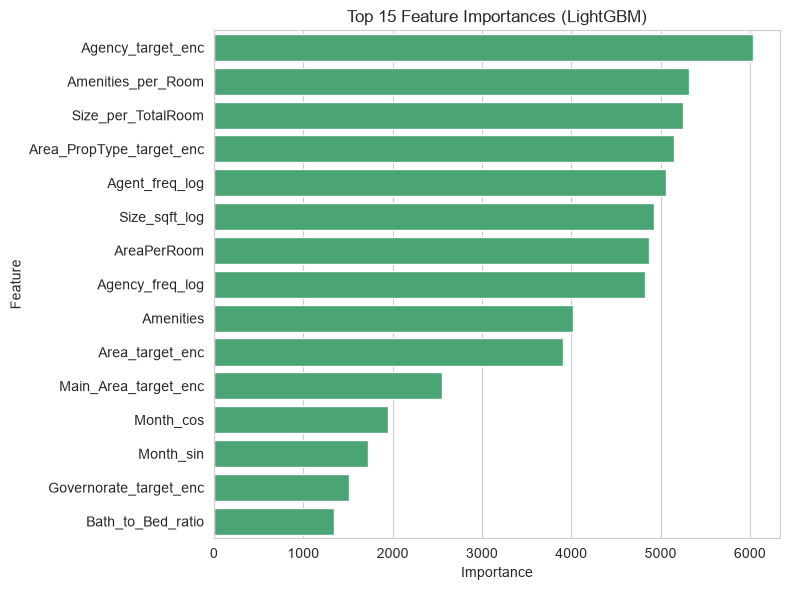

,Feature,Importance
10,Agency_target_enc,6035
22,Amenities_per_Room,5319
23,Size_per_TotalRoom,5255
11,Area_PropType_target_enc,5154
35,Agent_freq_log,5060
36,Size_sqft_log,4924
17,AreaPerRoom,4868
34,Agency_freq_log,4830
41,Amenities,4018
8,Area_target_enc,3909


In [41]:
best_booster_name = min(
    ['LightGBM', 'XGBoost', 'CatBoost'],
    key=lambda n: mean_absolute_error(
        y_val_orig, np.clip(np.expm1(tuned_pipelines[n].predict(X_val)), 0, None)
    )
)
best_booster_pipeline = tuned_pipelines[best_booster_name]

ohe_feature_names = ( 
    best_booster_pipeline.named_steps['preprocessor']
    .named_transformers_['cat'].named_steps['onehot']
    .get_feature_names_out(categorical_features)
)
target_enc_names = [f'{c}_target_enc' for c in target_encoded_features]
all_feature_names = list(ohe_feature_names) + target_enc_names + numeric_features + skewed_features

importances = best_booster_pipeline.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances}) \
    .sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='mediumseagreen')
plt.title(f'Top 15 Feature Importances ({best_booster_name})')
plt.tight_layout()
plt.show()

importance_df

In [42]:
# Pick whichever of the stacked ensemble or the weighted blend scored lower validation MAE
stack_row = results_df_final[results_df_final['Model'] == 'Stacked Ensemble (LGBM+XGB+CatBoost)'].iloc[0]
blend_row = results_df_final[results_df_final['Model'] == 'Weighted Blend (LGBM+XGB+CatBoost)'].iloc[0]
use_blend = blend_row['MAE'] < stack_row['MAE']
print(f"Stacked MAE: {stack_row['MAE']:.2f}  |  Blend MAE: {blend_row['MAE']:.2f}  ->  using {'BLEND' if use_blend else 'STACK'}")

X_test_final = test_clean[feature_cols]

if use_blend:
    # Refit each tuned booster on 100% of the training data, then combine with the fixed blend weights
    for name in ['LightGBM', 'XGBoost', 'CatBoost']:
        tuned_pipelines[name].fit(X, y)
    test_preds_full = np.vstack([
        np.clip(np.expm1(tuned_pipelines[n].predict(X_test_final)), 0, None)
        for n in ['LightGBM', 'XGBoost', 'CatBoost']
    ]).T
    test_pred = test_preds_full @ blend_weights
    print('Final blended model retrained on the full training dataset.')
else:
    stacking_model.fit(X, y)
    test_pred_log = stacking_model.predict(X_test_final)
    test_pred = np.clip(np.expm1(test_pred_log), 0, None)
    print('Final stacked model retrained on the full training dataset.')

test_pred[:10]

Stacked MAE: 93.00  |  Blend MAE: 92.51  ->  using BLEND
Final blended model retrained on the full training dataset.


array([450.47488616, 666.50311845, 757.3658528 , 348.78503233,
       291.30951885, 771.71276704, 926.57694995, 384.14915128,
       587.79521972, 444.22626412])

In [43]:
core_cols = ['Title', 'Area', 'Size_sqft', 'Beds_num', 'Baths_num']

lookup_map = train_clean.groupby(core_cols)['rent'].median()

test_keys = test_clean[core_cols]
matched = test_keys.set_index(core_cols).index.isin(lookup_map.index)
print(f"Test rows with an exact match in the training data: {matched.sum()} / {len(matched)}")

if matched.sum() > 0:
    matched_keys = test_keys[matched].set_index(core_cols).index
    test_pred[matched] = lookup_map.loc[matched_keys].values

test_pred[:10]


Test rows with an exact match in the training data: 248 / 3527


array([450.47488616, 666.50311845, 757.3658528 , 348.78503233,
       291.30951885, 771.71276704, 926.57694995, 400.        ,
       587.79521972, 444.22626412])

In [44]:
submission = pd.DataFrame({
    'Property_id': test['Property_id'],
    'Rent': test_pred   
})

submission.to_csv('submission.csv', index=False)
print('Final submission shape:', submission.shape)
submission.head()

Final submission shape: (3527, 2)


,Property_id,Rent
0,4394,450.474886
1,2338,666.503118
2,8531,757.365853
3,8952,348.785032
4,11064,291.309519
